In [1]:
from langgraph.graph import MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
import os
load_dotenv()
api_key = os.environ['GROQ_API_KEY1']
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append(SystemMessage(content=f"Conversation summary:\n{state['summary']}"))

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

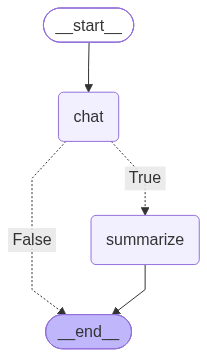

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='93147969-fa0e-45ad-ab04-f6faa6544739')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : **Quantum Physics in a Nutshell**

| Concept | What it means | Why it matters |



In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='93147969-fa0e-45ad-ab04-f6faa6544739'), AIMessage(content='**Quantum Physics in a Nutshell**\n\n| Concept | What it means | Why it matters |\n|---------|----------------|----------------|\n| **Wave‑particle duality** | Light and matter behave both as waves and as particles. | Explains phenomena like interference and photoelectric effect. |\n| **Heisenberg Uncertainty Principle** | You cannot know both position *x* and momentum *p* of a particle exactly: Δx\u202fΔp\u202f≥\u202fħ/2. | Sets fundamental limits on measurement and underpins quantum indeterminacy. |\n| **Superposition** | A quantum system can exist in multiple states simultaneously (e.g., a spin‑½ particle can be “up\u202f+\u202fdown”). | Enables quantum computing, interference patterns, and the “Schrödinger’s cat” paradox. |\n| **Entanglement** | Two or more particles share a joint state; measuring one instantly determines the other, reg

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='93147969-fa0e-45ad-ab04-f6faa6544739'), AIMessage(content='**Quantum Physics in a Nutshell**\n\n| Concept | What it means | Why it matters |\n|---------|----------------|----------------|\n| **Wave‑particle duality** | Light and matter behave both as waves and as particles. | Explains phenomena like interference and photoelectric effect. |\n| **Heisenberg Uncertainty Principle** | You cannot know both position *x* and momentum *p* of a particle exactly: Δx\u202fΔp\u202f≥\u202fħ/2. | Sets fundamental limits on measurement and underpins quantum indeterminacy. |\n| **Superposition** | A quantum system can exist in multiple states simultaneously (e.g., a spin‑½ particle can be “up\u202f+\u202fdown”). | Enables quantum computing, interference patterns, and the “Schrödinger’s cat” paradox. |\n| **Entanglement** | Two or more particles share a joint state; measuring one instantly determines the other, reg

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='93147969-fa0e-45ad-ab04-f6faa6544739'), AIMessage(content='**Quantum Physics in a Nutshell**\n\n| Concept | What it means | Why it matters |\n|---------|----------------|----------------|\n| **Wave‑particle duality** | Light and matter behave both as waves and as particles. | Explains phenomena like interference and photoelectric effect. |\n| **Heisenberg Uncertainty Principle** | You cannot know both position *x* and momentum *p* of a particle exactly: Δx\u202fΔp\u202f≥\u202fħ/2. | Sets fundamental limits on measurement and underpins quantum indeterminacy. |\n| **Superposition** | A quantum system can exist in multiple states simultaneously (e.g., a spin‑½ particle can be “up\u202f+\u202fdown”). | Enables quantum computing, interference patterns, and the “Schrödinger’s cat” paradox. |\n| **Entanglement** | Two or more particles share a joint state; measuring one instantly determines the other, reg

In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='757c581a-d8b0-4a90-a0d5-de47a00a608e'), AIMessage(content="## The Special Theory of Relativity – A “Quick‑Start” Guide\n\n| **What** | **Why it matters** |\n|----------|--------------------|\n| **Postulates** | 1. The laws of physics are the same in all inertial (non‑accelerating) frames. 2. The speed of light in vacuum, *c*, is the same for every observer, regardless of their motion. | These two simple ideas overturn the Newtonian notions of absolute space and time. |\n| **Key Consequences** | • Time dilation (moving clocks run slow). <br>• Length contraction (moving objects shrink along the direction of motion). <br>• Relativity of simultaneity (events that are simultaneous in one frame may not be in another). <br>• Mass–energy equivalence, \\(E=mc^2\\). | They explain real‑world phenomena (muon lifetimes, GPS satellite timing, particle accelerators) and form the foundation o